In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
# 加载数据
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv")

loan_status
0    35000
1    10000
Name: count, dtype: int64


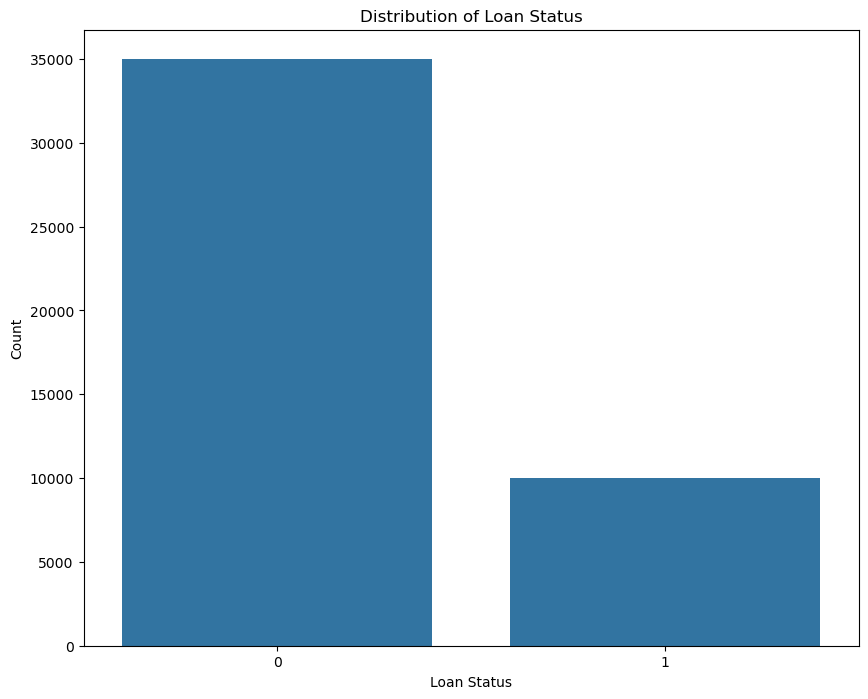

In [8]:
# 计算loan_status列中0和1的数量，按照比例过采样，得到如下结果
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 加载数据
# df = pd.read_csv("loan_data.csv")


loan_status_distribution = df['loan_status'].value_counts()

# 打印分布情况
print(loan_status_distribution)

# 可视化分布情况
plt.figure(figsize=(10, 8), dpi=100)
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\distribution_of_loan_status.png', dpi=600, bbox_inches='tight')
plt.show()

C:\Users\wjw20\AppData\Local\Temp\ipykernel_14740\4150196637.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='loan_status', data=df, palette='Paired') # 使用 'viridis' 调色板
C:\Users\wjw20\AppData\Local\Temp\ipykernel_14740\4150196637.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([status_labels.get(int(tick.get_text()), tick.get_text()) for tick in ax.get_xticklabels()], rotation=0, ha='center') # 如果标签长可以加 rotation


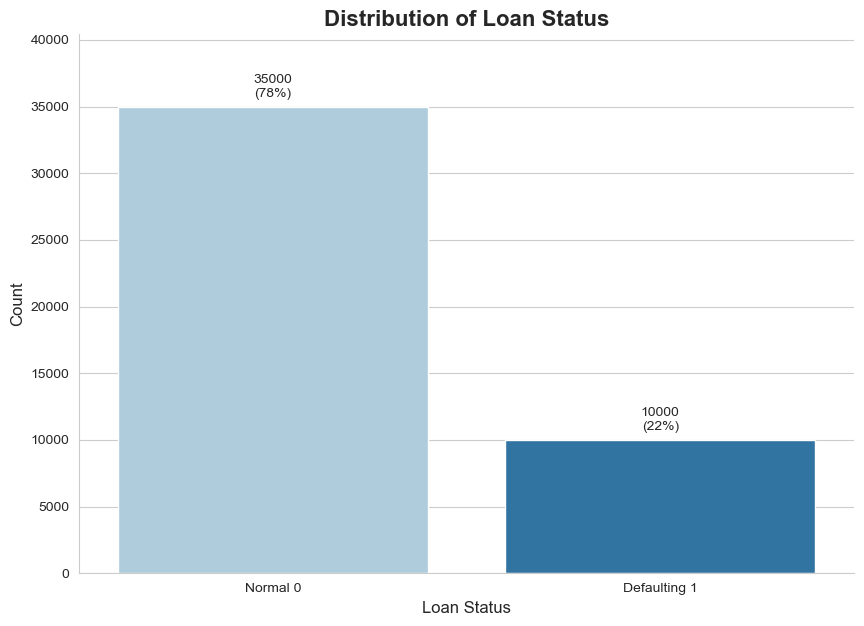

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # 假设你的数据在名为 df 的 DataFrame 中

# 假设你的 DataFrame 'df' 已经加载
# df = pd.read_csv('your_loan_data.csv') # 例如

# --- 准备工作 ---
loan_status_distribution = df['loan_status'].value_counts()
total_loans = len(df)

# --- 美化绘图 ---

# 1. 设置 Seaborn 样式 (可选，尝试不同的样式如 'whitegrid', 'darkgrid', 'ticks')
sns.set_style('whitegrid')

plt.figure(figsize=(10, 7), dpi=100) # 调整了 figsize

# 2. 创建 countplot 并指定调色板
#    你可以选择预设的调色板，如 'viridis', 'magma', 'Set2', 'Paired'
#    或者自定义颜色列表，例如: ['#3498db', '#e74c3c'] (蓝, 红)
ax = sns.countplot(x='loan_status', data=df, palette='Paired') # 使用 'viridis' 调色板

# 3. 添加更详细的标题和标签
plt.title('Distribution of Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Count', fontsize=12)

# --- 重要：修改 X 轴刻度标签 ---
# !!! 你需要根据你的数据含义替换这里的标签 !!!
status_labels = {0: 'Normal 0', 1: 'Defaulting 1'} # 这里的标签需要根据你的数据进行修改
ax.set_xticklabels([status_labels.get(int(tick.get_text()), tick.get_text()) for tick in ax.get_xticklabels()], rotation=0, ha='center') # 如果标签长可以加 rotation
# 如果不确定 0 和 1 的含义，可以暂时注释掉上面两行

# 4. 在柱状图顶部添加数据标签 (数量和百分比)
for p in ax.patches:
    count = p.get_height()
    percentage = f'{100 * count / total_loans:.0f}%'
    x = p.get_x() + p.get_width() / 2.
    y = p.get_height()
    # 在 annotate 内部将 count 转换为 int
    ax.annotate(f'{int(count)}\n({percentage})', (x, y), ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# 5. 移除顶部和右侧边框 (可选)
sns.despine()

# 调整 Y 轴上限，给标签留出空间
plt.ylim(0, ax.get_ylim()[1] * 1.1)

# 保存更高分辨率的图像
plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\distribution_of_loan_status.png', dpi=600, bbox_inches='tight')

plt.show()

In [4]:
cata_col = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
target = ['loan_status']
num_col = ['person_age', 'person_emp_exp', 'loan_percent_income', 'loan_int_rate', 'cb_person_cred_hist_length', 'credit_score']
#该数据集没有缺失值，无需处理缺失值
#去掉了离群值之后r方变低了，感觉不需要用
#我分了很多变量，这些是感觉能用的
#感觉不需要特征工程，里面包含了一些ratio，目前先直接就可以用了

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 加载数据并创建新特征
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv")
df['loan_income_percent'] = df['loan_amnt'] * df['loan_percent_income']

# 定义特征列和目标变量
cata_col = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
target = 'loan_status'
num_col = ['person_age', 'person_emp_exp', 'loan_income_percent', 'loan_int_rate', 'cb_person_cred_hist_length', 'credit_score']

# ========== 新增：离群值处理 ==========
def remove_outliers(df, columns, iqr_multiplier=2):
    """
    使用IQR方法删除离群值
    iqr_multiplier: 控制离群值范围的乘数（默认为2）
    """
    clean_df = df.copy()
    for col in columns:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_multiplier * IQR
        upper_bound = Q3 + iqr_multiplier * IQR
        
        # 保留在范围内的数据
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]
    print(f"删除离群值后剩余样本数：{len(clean_df)} (原数据：{len(df)})")
    return clean_df

# 执行离群值删除（注意：仅处理数值型特征）
df_clean = remove_outliers(df, num_col, iqr_multiplier=2)

# 重置索引
df_clean.reset_index(drop=True, inplace=True)

# ========== 继续原有流程 ==========
# One-Hot编码分类变量
df_encoded = pd.get_dummies(df_clean[cata_col], drop_first=True)

# 标准化数值特征
scaler = StandardScaler()
scaled_num = pd.DataFrame(scaler.fit_transform(df_clean[num_col]), columns=num_col)

# 合并特征
X = pd.concat([scaled_num, df_encoded], axis=1)
y = df_clean[target]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练逻辑回归模型
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 模型评估
y_pred = model.predict(X_test)
print("\n模型准确率:", accuracy_score(y_test, y_pred))
print("ROC AUC值:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("\n分类报告:")
print(classification_report(y_test, y_pred))

# 输出变量系数
coefficients = pd.DataFrame({'特征': X.columns, '系数值': model.coef_[0]})
print("\n逻辑回归系数:")
print(coefficients.sort_values('系数值', ascending=False))

删除离群值后剩余样本数：41537 (原数据：45000)

模型准确率: 0.8818006740491093
ROC AUC值: 0.9362466067133782

分类报告:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6622
           1       0.72      0.68      0.70      1686

    accuracy                           0.88      8308
   macro avg       0.82      0.81      0.81      8308
weighted avg       0.88      0.88      0.88      8308


逻辑回归系数:
                                    特征       系数值
13          person_home_ownership_RENT  1.212831
3                        loan_int_rate  0.802489
2                  loan_income_percent  0.502711
11         person_home_ownership_OTHER  0.138718
6                   person_gender_male  0.053335
8           person_education_Doctorate  0.032035
4           cb_person_cred_hist_length  0.012397
9         person_education_High School -0.007993
10             person_education_Master -0.014732
7            person_education_Bachelor -0.038337
1                       person_e

In [7]:
df_encoded = pd.get_dummies(df[cata_col], drop_first=True)
#这里是One-Hot

In [8]:
X = pd.concat([df[num_col], df_encoded], axis=1)
y = df[target]
df_combined = pd.concat([X, y], axis=1)

print("合并后的维度:", df_combined.shape)
print("\n前3行示例:")
print(df_combined)

#这里给你看一下

合并后的维度: (45000, 21)

前3行示例:
       person_age  person_emp_exp  loan_income_percent  loan_int_rate  \
0            22.0               0             17150.00          16.02   
1            21.0               0                80.00          11.14   
2            25.0               3              2420.00          12.87   
3            23.0               0             15400.00          15.23   
4            24.0               1             18550.00          14.27   
...           ...             ...                  ...            ...   
44995        27.0               6              4650.00          15.66   
44996        37.0              17              1260.00          14.07   
44997        33.0               7               138.55          10.02   
44998        29.0               4              4320.00          13.23   
44999        24.0               1               866.45          17.05   

       cb_person_cred_hist_length  credit_score  person_gender_male  \
0                       

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

# 加载数据并创建新特征
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\loan_data.csv")
df['loan_income_percent'] = df['loan_amnt'] * df['loan_percent_income']
# 定义特征列和目标变量
cata_col = ['person_gender','person_education','person_home_ownership','loan_intent','previous_loan_defaults_on_file']
target = 'loan_status'
num_col = ['person_age', 'person_emp_exp', 'loan_percent_income', 'loan_int_rate', 'cb_person_cred_hist_length', 'credit_score']

# One-Hot编码分类变量
df_encoded = pd.get_dummies(df[cata_col], drop_first=True)

# 标准化数值特征
scaler = StandardScaler()
scaled_num = pd.DataFrame(scaler.fit_transform(df[num_col]), columns=num_col)

# 合并特征
X = pd.concat([scaled_num, df_encoded], axis=1)
y = df[target]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 训练逻辑回归模型
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 模型评估
y_pred = model.predict(X_test)
print("模型准确率:", accuracy_score(y_test, y_pred))
print("ROC AUC值:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))
print("\n分类报告:")
print(classification_report(y_test, y_pred))

# 输出变量系数
coefficients = pd.DataFrame({'特征': X.columns, '系数值': model.coef_[0]})
print("\n逻辑回归系数:")
print(coefficients)

模型准确率: 0.8874444444444445
ROC AUC值: 0.9484244727720482

分类报告:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.76      0.72      0.74      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.89      0.89      0.89      9000


逻辑回归系数:
                                    特征       系数值
0                           person_age  0.061875
1                       person_emp_exp -0.081529
2                  loan_percent_income  0.955364
3                        loan_int_rate  0.905345
4           cb_person_cred_hist_length -0.008916
5                         credit_score -0.448385
6                   person_gender_male  0.010835
7            person_education_Bachelor -0.050042
8           person_education_Doctorate -0.041004
9         person_education_High School -0.003629
10             person_education_Master -0.018279
11         per

In [19]:
import pandas as pd

# 假设已有:
# X = 特征矩阵（包含One-Hot编码后的DataFrame）
# y = 目标变量（Series或DataFrame）

# 方法1：直接拼接（要求索引对齐）
df_combined = pd.concat([X, y], axis=1)

# 方法2：重置索引后拼接（适用于索引混乱的情况）

# 验证合并结果
print("合并后的维度:", df_combined.shape)
print("\n前3行示例:")
print(df_combined)

#这里是标准化后的df

合并后的维度: (45000, 21)

前3行示例:
       person_age  person_emp_exp  loan_percent_income  loan_int_rate  \
0       -0.953538       -0.892284             4.016394       1.683039   
1       -1.118963       -0.892284            -0.684829       0.044782   
2       -0.457264       -0.397517             3.443074       0.625557   
3       -0.788113       -0.892284             3.443074       1.417829   
4       -0.622689       -0.727362             4.475050       1.095549   
...           ...             ...                  ...            ...   
44995   -0.126414        0.097249             1.952442       1.562184   
44996    1.527834        1.911393             0.003155       1.028407   
44997    0.866135        0.262171            -1.028821      -0.331212   
44998    0.204436       -0.232595             2.525762       0.746412   
44999   -0.622689       -0.727362            -0.111509       2.028819   

       cb_person_cred_hist_length  credit_score  person_gender_male  \
0                       

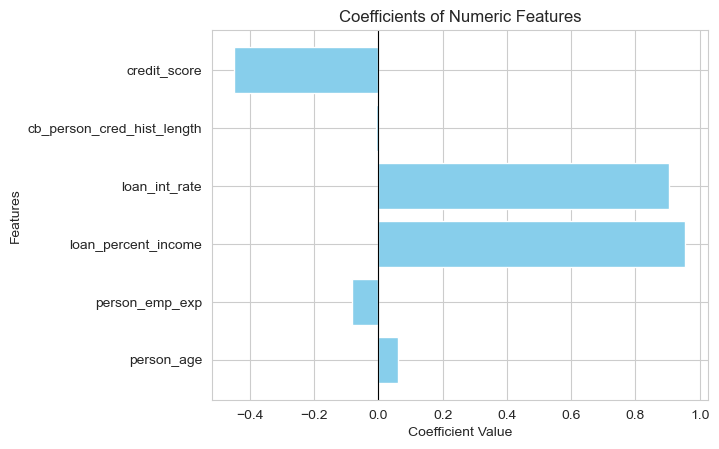

In [20]:
import matplotlib.pyplot as plt

# Correctly structured coefficients dictionary
coefficients = {
    "person_age": 0.061875,
    "person_emp_exp": -0.081529,
    "loan_percent_income": 0.955364,
    "loan_int_rate": 0.905345,
    "cb_person_cred_hist_length": -0.008916,
    "credit_score": -0.448385

}

# Creating a figure and axis
fig, ax = plt.subplots()

# Plotting the bar chart
ax.barh(list(coefficients.keys()), list(coefficients.values()), color='skyblue')

# Drawing a vertical line at 0
ax.axvline(x=0, color='black', linewidth=0.8)

# Setting the title and axis labels
ax.set_title('Coefficients of Numeric Features')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Features')

plt.show()

#这里进行了逻辑回归之后，数值化变量的β值，>0的变量是增加风险（贷款越容易不过），小于0的变量是减少风险（贷款越容易过）

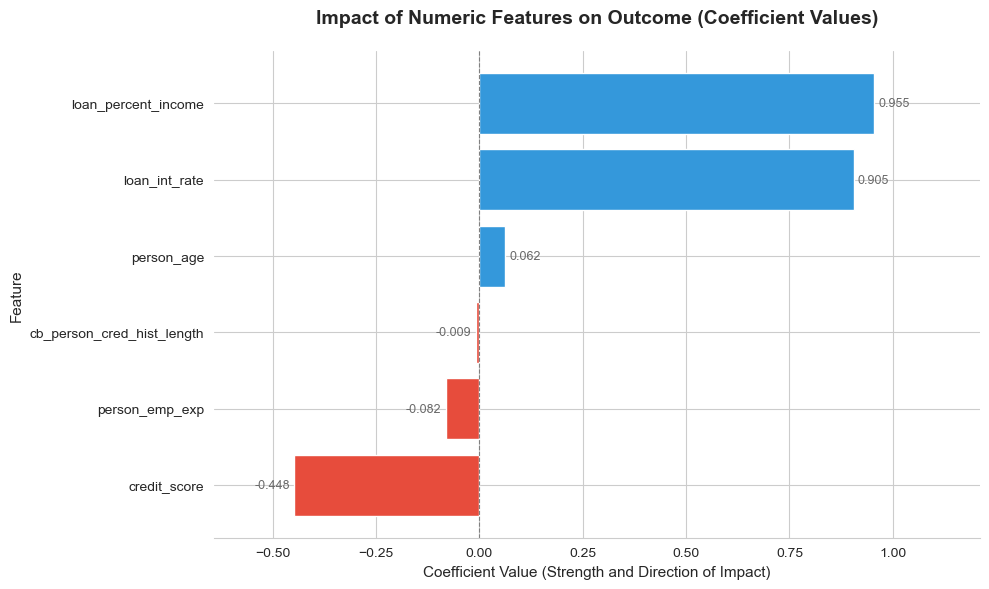

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for styling

# Coefficients dictionary
coefficients = {
    "person_age": 0.061875,
    "person_emp_exp": -0.081529,
    "loan_percent_income": 0.955364,
    "loan_int_rate": 0.905345,
    "cb_person_cred_hist_length": -0.008916,
    "credit_score": -0.448385
}

# --- 1. Data Preparation: Sort and Prepare Colors ---
# Sort coefficients by value (ascending) for better visualization
sorted_coeffs = sorted(coefficients.items(), key=lambda item: item[1])
features = [item[0] for item in sorted_coeffs]
values = [item[1] for item in sorted_coeffs]

# Create colors based on value sign
# Using common convention: blue for positive, red for negative
colors = ['#e74c3c' if v < 0 else '#3498db' for v in values]

# --- 2. Plotting and Styling ---
# Set a nice Seaborn style
sns.set_style('whitegrid')

# Create figure and axes, adjust figure size
fig, ax = plt.subplots(figsize=(10, 6), dpi=100) # Wider and slightly shorter

# Plotting the sorted horizontal bar chart with specific colors
bars = ax.barh(features, values, color=colors)

# Drawing a vertical line at 0 - make it slightly less prominent
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')

# --- 3. Add Value Labels ---
# Iterate through the bars and add text labels
for bar in bars:
    width = bar.get_width()
    # Position label slightly outside the bar end
    label_x_pos = width + (0.01 if width >= 0 else -0.01)
    # Set horizontal alignment based on bar direction
    ha = 'left' if width >= 0 else 'right'
    # Add the text
    ax.text(label_x_pos,           # x position
            bar.get_y() + bar.get_height() / 2, # y position (center of the bar)
            f'{width:.3f}',        # Text label, formatted to 3 decimal places
            ha=ha,                 # Horizontal alignment
            va='center',           # Vertical alignment
            fontsize=9,            # Font size for labels
            color='dimgray')       # Label color

# --- 4. Refine Labels, Title, and Limits ---
# Setting the title and axis labels with adjusted fonts
ax.set_title('Impact of Numeric Features on Outcome (Coefficient Values)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Coefficient Value (Strength and Direction of Impact)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)

# Adjust x-axis limits to give space for labels at the ends of bars
xmin, xmax = ax.get_xlim()
padding = 0.1 * (xmax - xmin) # Add 10% relative padding
# Give slightly more padding on the right if there are large positive values
ax.set_xlim(xmin - padding * 0.8, xmax + padding * 1.2)

# --- 5. Despine ---
# Remove top and right spines for a cleaner look
sns.despine(left=True, bottom=False) # Keep bottom spine, remove y-axis line if desired

# Improve layout to prevent labels overlapping
plt.tight_layout()
plt.savefig(r'D:\GitHubRepos\is6400-business-data-analytics\loan_data_analytics\image\result_figs\impact_of_numeric_features_on_outcome.png', 
                dpi=600, 
                bbox_inches='tight',
                transparent=False)

plt.show()

In [19]:
from mlxtend.feature_selection import SequentialFeatureSelector

# 需要先安装mlxtend：pip install mlxtend
forward_selector = SequentialFeatureSelector(
    LogisticRegression(max_iter=1000),
    k_features='best',
    forward=True,
    scoring='accuracy',
    cv=5
).fit(X_train, y_train)

selected_features = X.columns[list(forward_selector.k_feature_idx_)]
print("向前选择保留的特征:", selected_features.tolist())

#由于有很多的变量，这里是通过“向前选择法”来筛选最好的变量

向前选择保留的特征: ['loan_percent_income', 'loan_int_rate', 'credit_score', 'person_education_Bachelor', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes']


In [69]:
selected_features = ['loan_percent_income', 'loan_int_rate', 'credit_score', 'person_education_Bachelor', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes']

In [71]:
# 使用向后消除的结果示例
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 重新训练模型
model_selected = LogisticRegression(max_iter=1000)
model_selected.fit(X_train_selected, y_train)

# 评估优化后的模型
y_pred_selected = model_selected.predict(X_test_selected)
print("\n优化后模型准确率:", accuracy_score(y_test, y_pred_selected))
print("优化后ROC AUC值:", roc_auc_score(y_test, model_selected.predict_proba(X_test_selected)[:, 1]))

# 对比特征数量变化
print(f"\n特征数量：{X.shape[1]} → {len(selected_features)}")


优化后模型准确率: 0.8887777777777778
优化后ROC AUC值: 0.948216570936448

特征数量：20 → 10



优化后模型准确率: 0.8887777777777778
优化后ROC AUC值: 0.948216570936448

特征数量：20 → 10


C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23458 (\N{CJK UNIFIED IDEOGRAPH-5BA2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36829 (\N{CJK UNIFIED IDEOGRAPH-8FDD}) missing from font(s) DejaVu San

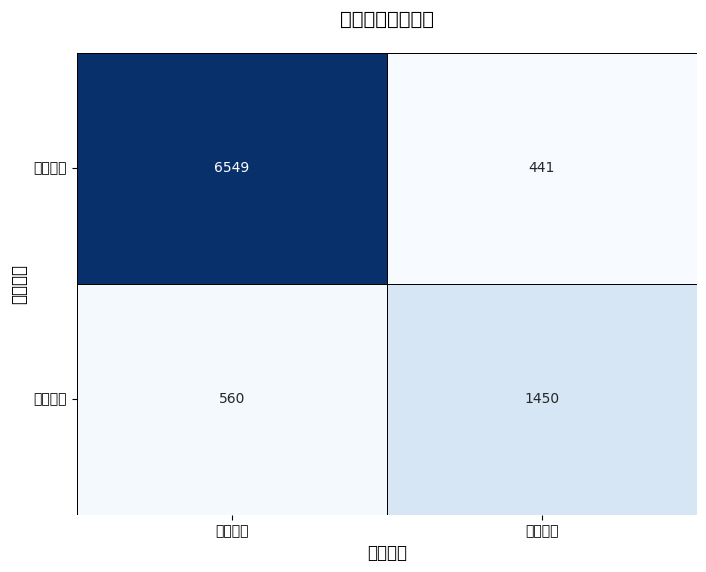


============= 详细性能指标 =============
真阴性（TN）: 6549      → 正确识别的正常客户
假阳性（FP）: 441      → 误判为违约的正常客户
假阴性（FN）: 560      → 漏判的真实违约客户
真阳性（TP）: 1450      → 正确识别的违约客户

召回率（Recall）: 72.1%  → 违约客户识别率
精确率（Precision）: 76.7%  → 违约预警准确率



In [73]:
from sklearn.metrics import confusion_matrix

# 使用向后消除的结果示例
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# 重新训练模型
model_selected = LogisticRegression(max_iter=1000)
model_selected.fit(X_train_selected, y_train)

# 评估优化后的模型
y_pred_selected = model_selected.predict(X_test_selected)
print("\n优化后模型准确率:", accuracy_score(y_test, y_pred_selected))
print("优化后ROC AUC值:", roc_auc_score(y_test, model_selected.predict_proba(X_test_selected)[:, 1]))

# 对比特征数量变化
print(f"\n特征数量：{X.shape[1]} → {len(selected_features)}")

# ========== 混淆矩阵可视化 ==========
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_selected)
sns.heatmap(cm, 
           annot=True, 
           fmt="d", 
           cmap="Blues",
           linewidths=0.5,
           linecolor="black",
           cbar=False)

plt.title("优化模型混淆矩阵", fontsize=14, pad=20)
plt.xlabel("预测标签", fontsize=12)
plt.ylabel("真实标签", fontsize=12)
plt.xticks([0.5, 1.5], ["正常客户", "违约客户"])
plt.yticks([0.5, 1.5], ["正常客户", "违约客户"], rotation=0)
plt.show()

# 添加性能指标解读
tn, fp, fn, tp = cm.ravel()
print(f'''
============= 详细性能指标 =============
真阴性（TN）: {tn}      → 正确识别的正常客户
假阳性（FP）: {fp}      → 误判为违约的正常客户
假阴性（FN）: {fn}      → 漏判的真实违约客户
真阳性（TP）: {tp}      → 正确识别的违约客户

召回率（Recall）: {tp/(tp+fn):.1%}  → 违约客户识别率
精确率（Precision）: {tp/(tp+fp):.1%}  → 违约预警准确率
''')

In [23]:
selected_features

['loan_percent_income',
 'loan_int_rate',
 'credit_score',
 'person_education_Bachelor',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'previous_loan_defaults_on_file_Yes']

In [25]:
# 需要筛选的特征列表


# 创建完整系数表
full_coefficients = pd.DataFrame({
    '特征': X.columns,
    '系数值': model.coef_[0],
    '绝对值': np.abs(model.coef_[0])
})

# 筛选指定特征
selected_coefficients = full_coefficients[
    full_coefficients['特征'].isin(selected_features)
].sort_values('绝对值', ascending=False)

# 格式化输出
print("选定特征的逻辑回归系数：")
print(selected_coefficients.drop(columns='绝对值').to_string(index=False))

# 输出特征方向解释
print("\n系数解读：")
print("- 正系数表示该特征增加时，贷款违约概率上升")
print("- 负系数表示该特征增加时，贷款违约概率下降")

选定特征的逻辑回归系数：
                                特征       系数值
previous_loan_defaults_on_file_Yes -7.712455
               loan_intent_VENTURE -1.171271
        person_home_ownership_RENT  1.035038
         person_home_ownership_OWN -0.967080
               loan_percent_income  0.955364
                     loan_int_rate  0.905345
             loan_intent_EDUCATION -0.833721
              loan_intent_PERSONAL -0.666297
                      credit_score -0.448385
         person_education_Bachelor -0.050042

系数解读：
- 正系数表示该特征增加时，贷款违约概率上升
- 负系数表示该特征增加时，贷款违约概率下降


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# 假设scaled_num和df_encoded已经准备好，并且target变量已经被正确设置
X = pd.concat([scaled_num, df_encoded], axis=1)
y = df[target]

selected_features = ['loan_percent_income',
'loan_int_rate',
'credit_score',
'person_education_Bachelor',
'person_home_ownership_OWN',
'person_home_ownership_RENT',
'loan_intent_EDUCATION',
'loan_intent_PERSONAL',
'loan_intent_VENTURE',
'previous_loan_defaults_on_file_Yes']

# 确保只选取selected_features中指定的特征
X_selected = X[selected_features]

# 数据集分割
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# 创建随机森林模型
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 获取特征重要性
feature_importances = model.feature_importances_

# 创建特征重要性的DataFrame
features_df = pd.DataFrame({'Feature': selected_features, 'Importance': feature_importances})
features_df.sort_values(by='Importance', ascending=False, inplace=True)

print(features_df)

                              Feature  Importance
1                       loan_int_rate    0.247682
0                 loan_percent_income    0.245398
9  previous_loan_defaults_on_file_Yes    0.244965
2                        credit_score    0.155338
5          person_home_ownership_RENT    0.058029
8                 loan_intent_VENTURE    0.010739
6               loan_intent_EDUCATION    0.009820
4           person_home_ownership_OWN    0.009745
3           person_education_Bachelor    0.009640
7                loan_intent_PERSONAL    0.008644


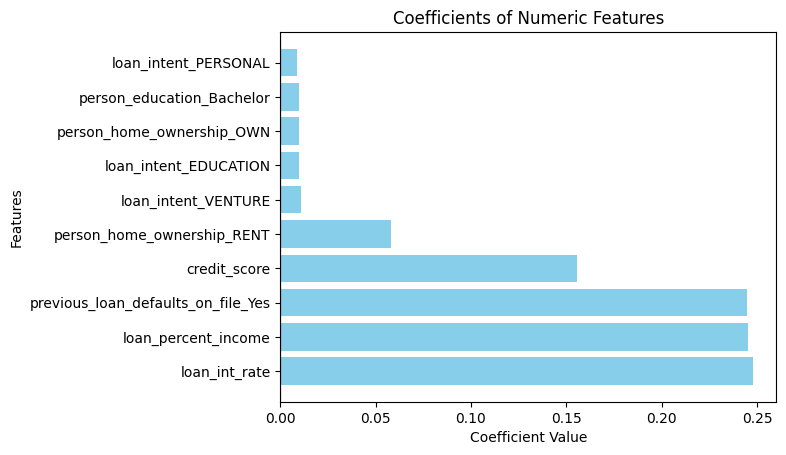

In [28]:
import matplotlib.pyplot as plt

# 修正系数及其对应的特征名称格式
coefficients = {
    'loan_int_rate': 0.247682,
    'loan_percent_income': 0.245398,
    'previous_loan_defaults_on_file_Yes': 0.244965,
    'credit_score': 0.155338,
    'person_home_ownership_RENT': 0.058029,
    'loan_intent_VENTURE': 0.010739,
    'loan_intent_EDUCATION': 0.009820,
    'person_home_ownership_OWN': 0.009745,
    'person_education_Bachelor': 0.009640,
    'loan_intent_PERSONAL': 0.008644
}

# 创建一个图形和坐标轴
fig, ax = plt.subplots()

# 绘制条形图
ax.barh(list(coefficients.keys()), list(coefficients.values()), color='skyblue')

# 在0处绘制一条垂直线
ax.axvline(x=0, color='black', linewidth=0.8)

# 设置标题和轴标签
ax.set_title('Coefficients of Numeric Features')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Features')

plt.show()

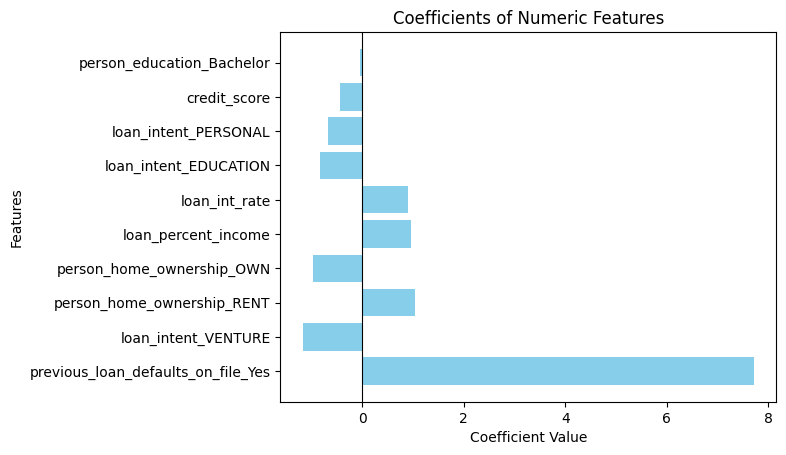

In [31]:
import matplotlib.pyplot as plt

# 系数及其对应的特征名称（纠正格式）
coefficients = {
    "previous_loan_defaults_on_file_Yes": 7.712455,
    "loan_intent_VENTURE": -1.171271,
    "person_home_ownership_RENT": 1.035038,
    "person_home_ownership_OWN": -0.967080,
    "loan_percent_income": 0.955364,
    "loan_int_rate": 0.905345,
    "loan_intent_EDUCATION": -0.833721,
    "loan_intent_PERSONAL": -0.666297,
    "credit_score": -0.448385,
    "person_education_Bachelor": -0.050042
}

# 创建一个图形和坐标轴
fig, ax = plt.subplots()

# 绘制条形图
ax.barh(list(coefficients.keys()), list(coefficients.values()), color='skyblue')

# 在0处绘制一条垂直线
ax.axvline(x=0, color='black', linewidth=0.8)

# 设置标题和轴标签
ax.set_title('Coefficients of Numeric Features')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Features')

plt.show()
#这里进行了逻辑回归之后，所有变量的β值，>0的变量是增加风险（贷款越容易不过），小于0的变量是减少风险（贷款越容易过）

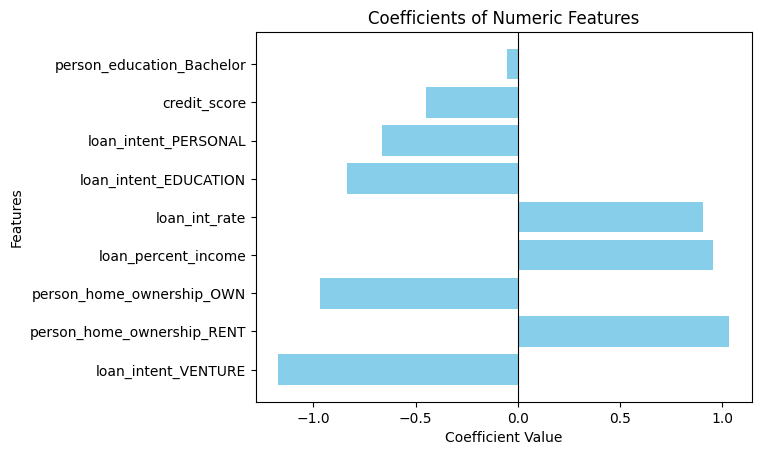

In [33]:
import matplotlib.pyplot as plt

# 系数及其对应的特征名称（纠正格式）
coefficients = {
    "loan_intent_VENTURE": -1.171271,
    "person_home_ownership_RENT": 1.035038,
    "person_home_ownership_OWN": -0.967080,
    "loan_percent_income": 0.955364,
    "loan_int_rate": 0.905345,
    "loan_intent_EDUCATION": -0.833721,
    "loan_intent_PERSONAL": -0.666297,
    "credit_score": -0.448385,
    "person_education_Bachelor": -0.050042
}

# 创建一个图形和坐标轴
fig, ax = plt.subplots()

# 绘制条形图
ax.barh(list(coefficients.keys()), list(coefficients.values()), color='skyblue')

# 在0处绘制一条垂直线
ax.axvline(x=0, color='black', linewidth=0.8)

# 设置标题和轴标签
ax.set_title('Coefficients of Numeric Features')
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Features')

plt.show()
#这里进行了逻辑回归之后，去掉了previous_loan_defaults_on_file_Yes数值化变量的β值。

In [29]:
df_combined

,person_age,person_emp_exp,loan_percent_income,loan_int_rate,cb_person_cred_hist_length,credit_score,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes,loan_status
0,-0.953538,-0.892284,4.016394,1.683039,-0.739109,-1.419814,False,False,False,False,...,False,False,True,False,False,False,True,False,False,1
1,-1.118963,-0.892284,-0.684829,0.044782,-0.996863,-2.549975,False,False,False,True,...,False,True,False,True,False,False,False,False,True,0
2,-0.457264,-0.397517,3.443074,0.625557,-0.739109,0.047412,False,False,False,True,...,False,False,False,False,False,True,False,False,False,1
3,-0.788113,-0.892284,3.443074,1.417829,-0.996863,0.840507,False,True,False,False,...,False,False,True,False,False,True,False,False,False,1
4,-0.622689,-0.727362,4.475050,1.095549,-0.481354,-0.924130,True,False,False,False,...,False,False,True,False,False,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,-0.126414,0.097249,1.952442,1.562184,-0.739109,0.245686,True,False,False,False,...,False,False,True,False,False,True,False,False,False,1
44996,1.527834,1.911393,0.003155,1.028407,1.322928,-0.230171,False,False,False,False,...,False,False,True,False,True,False,False,False,False,1
44997,0.866135,0.262171,-1.028821,-0.331212,1.065174,0.701716,True,False,False,False,...,False,False,True,False,False,False,False,False,False,1
44998,0.204436,-0.232595,2.525762,0.746412,0.034155,-0.567237,True,True,False,False,...,False,False,True,True,False,False,False,False,False,1


C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\21472\AppData\Local\Temp\ipykernel_57544\2184071692.py:54: UserWarning: Glyph 24067 (\

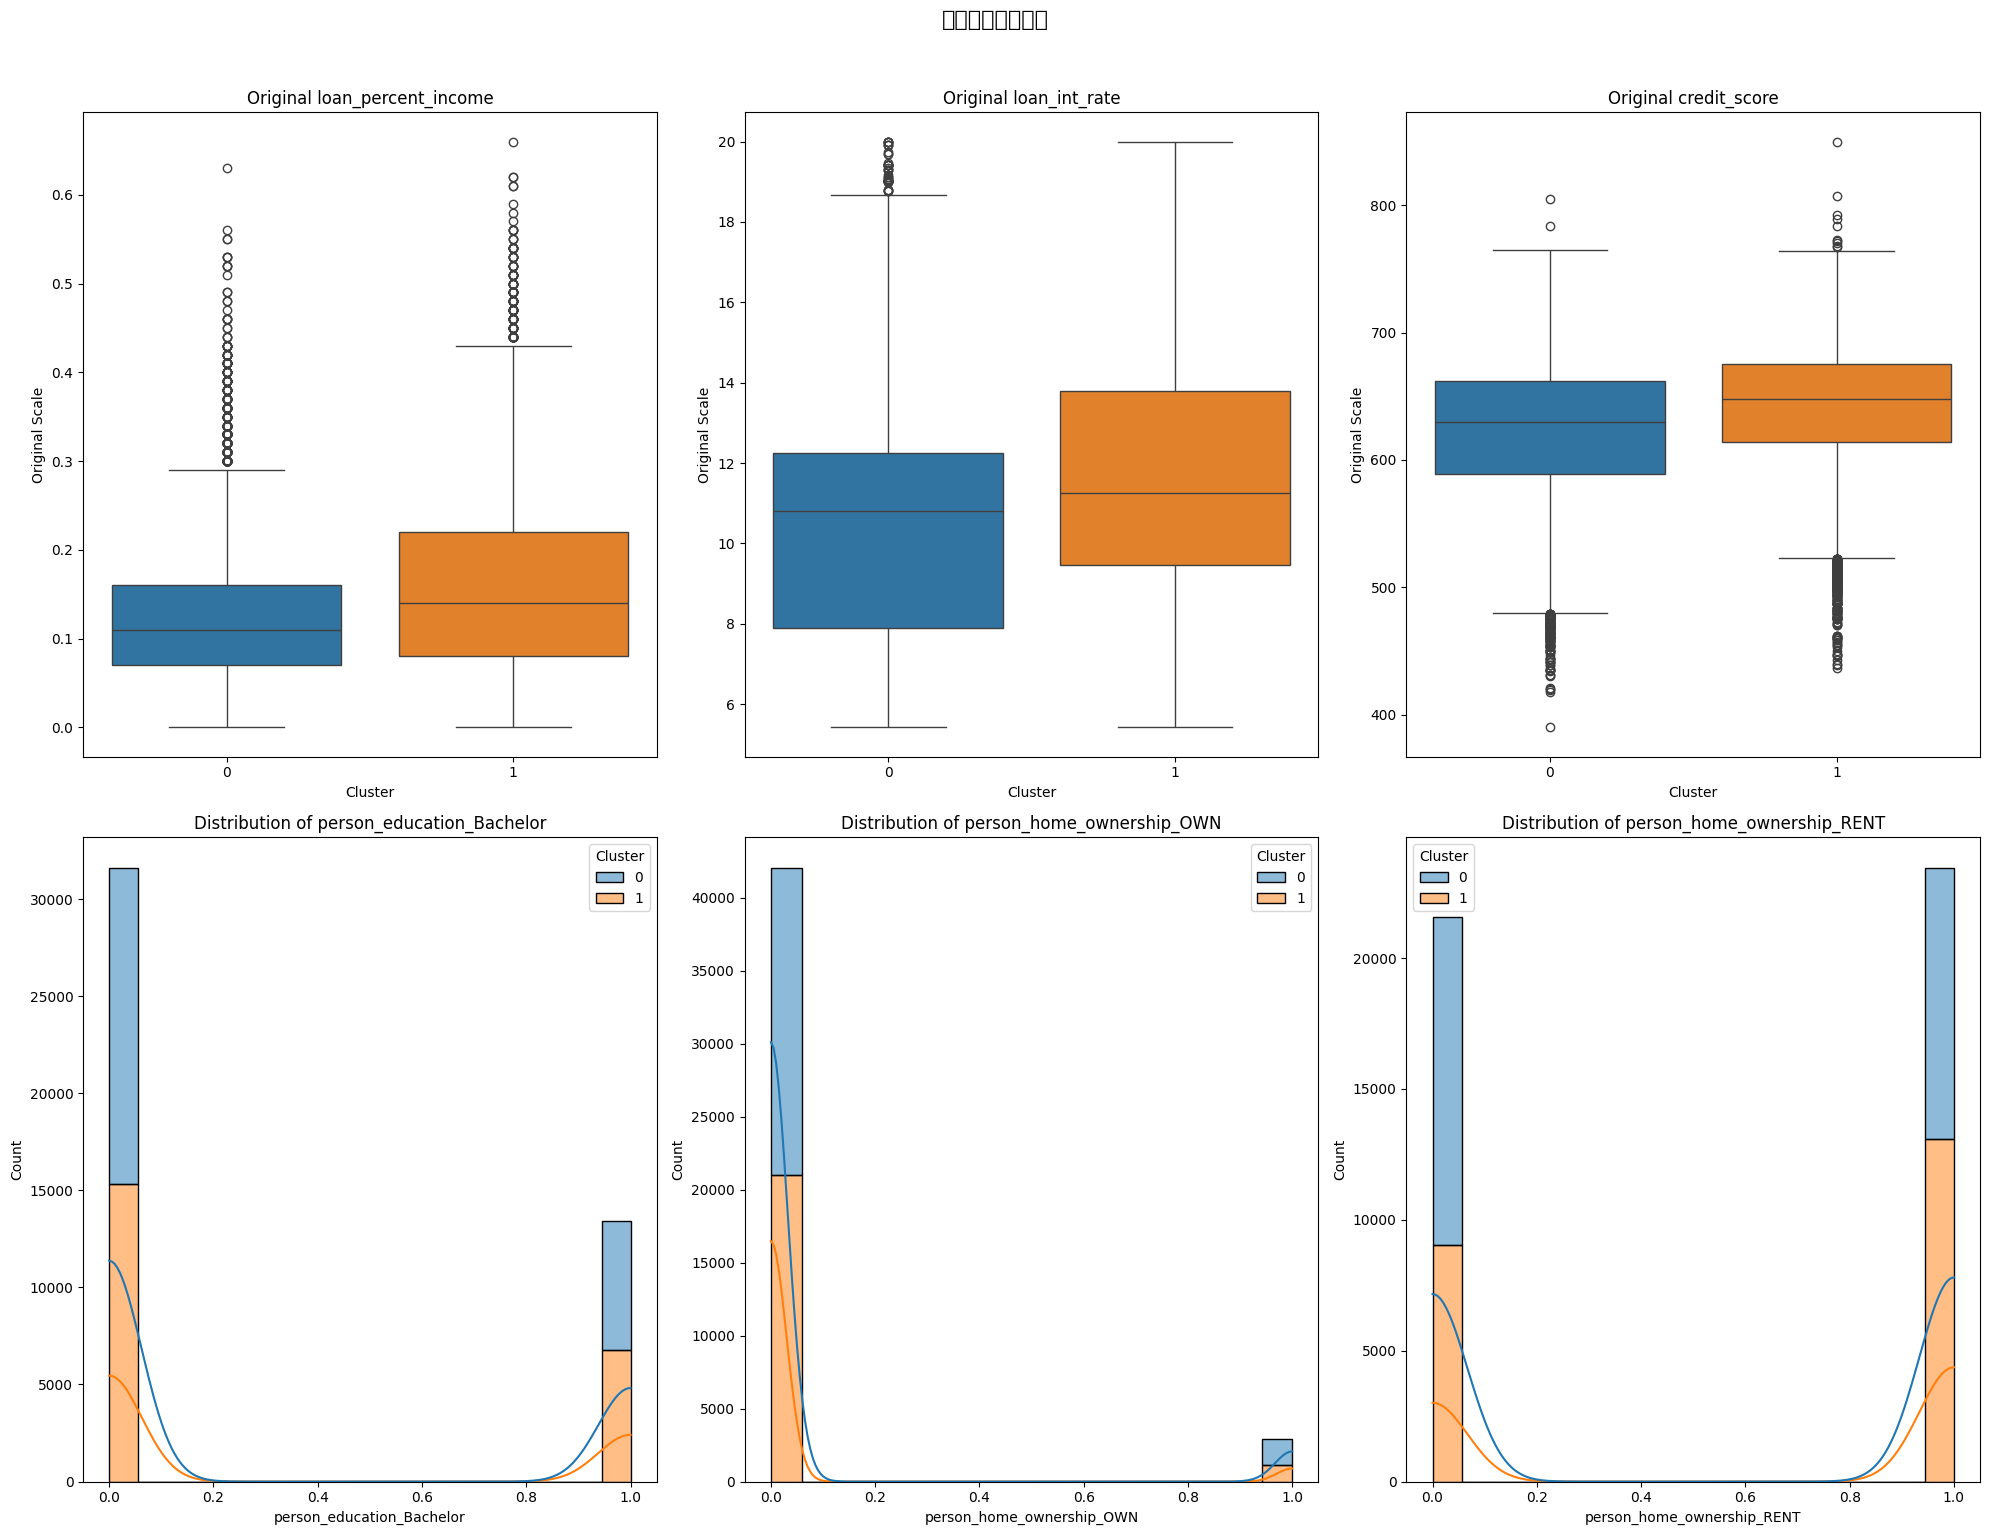

=== 客户分群风险画像 ===


,贷款收入比_均值,贷款收入比_中位数,贷款利率_均值,贷款利率_最大值,信用分_均值,信用分_最小值,信用分_最大值,person_education_Bachelor_比例,person_home_ownership_OWN_比例,person_home_ownership_RENT_比例,loan_intent_EDUCATION_比例,loan_intent_PERSONAL_比例,loan_intent_VENTURE_比例,previous_loan_defaults_on_file_Yes_比例,person_education_Bachelor_数量,person_home_ownership_OWN_数量,person_home_ownership_RENT_数量,loan_intent_EDUCATION_数量,loan_intent_PERSONAL_数量,loan_intent_VENTURE_数量,previous_loan_defaults_on_file_Yes_数量,违约客户数,总客户数,客户占比,违约率,风险等级
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.1%,0.1%,10.5%,20.0%,623,390,805,29.0%,662500.0%,7.9%,181200.0%,45.2%,1034800.0%,21.9%,5013,0.169194,3871,0.193496,4427,0.998645,22848,3,22879,50.8%,0.0%,低风险
1,0.2%,0.1%,11.6%,20.0%,642,437,850,30.6%,677400.0%,5.1%,113900.0%,59.2%,1309500.0%,18.7%,4140,0.166403,3681,0.153338,3392,0.000452,10,9997,22121,49.2%,45.2%,高风险


C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32676 (\N{CJK UNIFIED IDEOGRAPH-7FA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\21472\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu San

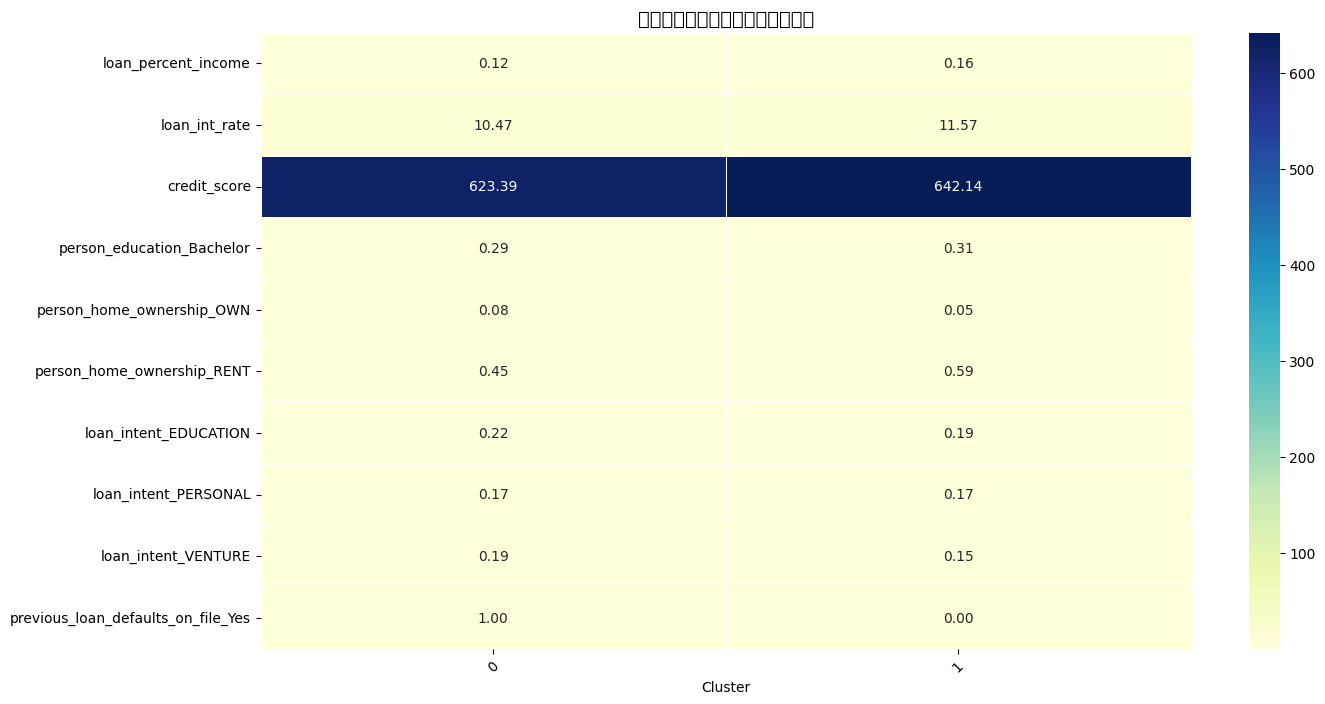

In [49]:
# -*- coding: utf-8 -*-
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ========== 全局参数配置 Global Parameters ==========
SELECTED_FEATURES = [
    'loan_percent_income', 'loan_int_rate', 'credit_score',
    'person_education_Bachelor', 'person_home_ownership_OWN',
    'person_home_ownership_RENT', 'loan_intent_EDUCATION',
    'loan_intent_PERSONAL', 'loan_intent_VENTURE',
    'previous_loan_defaults_on_file_Yes'
]
CLUSTER_NUM = 2
PLOT_COLORS = ['#1f77b4', '#ff7f0e']  # 聚类配色 Cluster colors

# ========== 数据预处理 Data Preprocessing ==========
# 复制原始数据（保护性操作） Protect original data
df_processed = df_combined[SELECTED_FEATURES + ['loan_status']].copy()

# 标准化特征仅用于聚类（保留原始数据用于分析）
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_processed[SELECTED_FEATURES])

# ========== 聚类分析 Cluster Analysis ==========
kmeans = KMeans(n_clusters=CLUSTER_NUM, random_state=42, n_init=20)
df_processed['Cluster'] = kmeans.fit_predict(scaled_features)  # 使用标准化数据聚类

# ========== 可视化分析 Visualization ==========
plt.figure(figsize=(20, 15))

# 1. 原始数据分布矩阵（使用原始特征） Original feature distribution
for i, feature in enumerate(SELECTED_FEATURES[:3], 1):
    plt.subplot(2,3,i)
    sns.boxplot(
        x='Cluster', y=feature, data=df_processed, 
        palette=PLOT_COLORS, hue='Cluster', legend=False
    )
    plt.title(f'Original {feature}', fontsize=12)
    plt.ylabel('Original Scale')

# 2. 原始数据分布直方图
for i, feature in enumerate(SELECTED_FEATURES[3:6], 4):
    plt.subplot(2,3,i)
    sns.histplot(
        data=df_processed, x=feature, hue='Cluster',
        palette=PLOT_COLORS, kde=True, multiple='stack'
    )
    plt.title(f'Distribution of {feature}')
    
plt.suptitle('原始特征分布分析', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# ========== 业务报告生成 Business Report ==========
# 聚合原始特征数据（全部使用原始值）
report_data = df_processed.groupby('Cluster').agg({
    # 数值型特征（原始值）
    'loan_percent_income': ['mean', 'median'],
    'loan_int_rate': ['mean', lambda x: f"{x.max():.1f}%"],  # 显示原始百分比
    'credit_score': ['mean', 'min', 'max'],
    
    # 二元特征（原始值）
    **{col: ['mean', 'sum'] for col in [
        'person_education_Bachelor',
        'person_home_ownership_OWN',
        'person_home_ownership_RENT',
        'loan_intent_EDUCATION',
        'loan_intent_PERSONAL',
        'loan_intent_VENTURE',
        'previous_loan_defaults_on_file_Yes'
    ]},
    
    # 目标变量（原始值）
    'loan_status': [
        ('default_count', 'sum'), 
        ('total_clients', 'count')
    ]
})

# 列名格式化
report_data.columns = [
    # 数值型
    '贷款收入比_均值', '贷款收入比_中位数',
    '贷款利率_均值', '贷款利率_最大值',
    '信用分_均值', '信用分_最小值', '信用分_最大值',
    
    # 二元特征
    *[f"{col}_比例" for col in SELECTED_FEATURES[3:]],
    *[f"{col}_数量" for col in SELECTED_FEATURES[3:]],
    
    # 目标变量
    '违约客户数', '总客户数'
]

# 添加业务指标
report_data['客户占比'] = report_data['总客户数'] / report_data['总客户数'].sum()
report_data['违约率'] = report_data['违约客户数'] / report_data['总客户数']
report_data['风险等级'] = pd.cut(
    report_data['违约率'],
    bins=[0, 0.1, 0.3, 1],
    labels=['低风险', '中风险', '高风险']
)

# 生成交互式报告
print("=== 客户分群风险画像 ===")
display(
    report_data.style
    .format({
        '贷款收入比_均值': '{:.1f}%',
        '贷款收入比_中位数': '{:.1f}%',
        '贷款利率_均值': '{:.1f}%',
        '客户占比': '{:.1%}',
        '违约率': '{:.1%}',
        '信用分_均值': '{:.0f}',
        **{col+'_比例': '{:.1%}' for col in SELECTED_FEATURES[3:]}
    })
    .background_gradient(subset=['违约率'], cmap='Reds')
    .bar(subset=['客户占比'], color='#5fba7d')
    .set_caption("基于原始数据的客户分群分析")
)

# ========== 业务特征热力图 ==========
plt.figure(figsize=(15,8))
sns.heatmap(
    df_processed.groupby('Cluster')[SELECTED_FEATURES].mean().T,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    linewidths=0.5
)
plt.title('各分群特征均值对比（原始数值）', fontsize=14)
plt.xticks(rotation=45)
plt.show() 

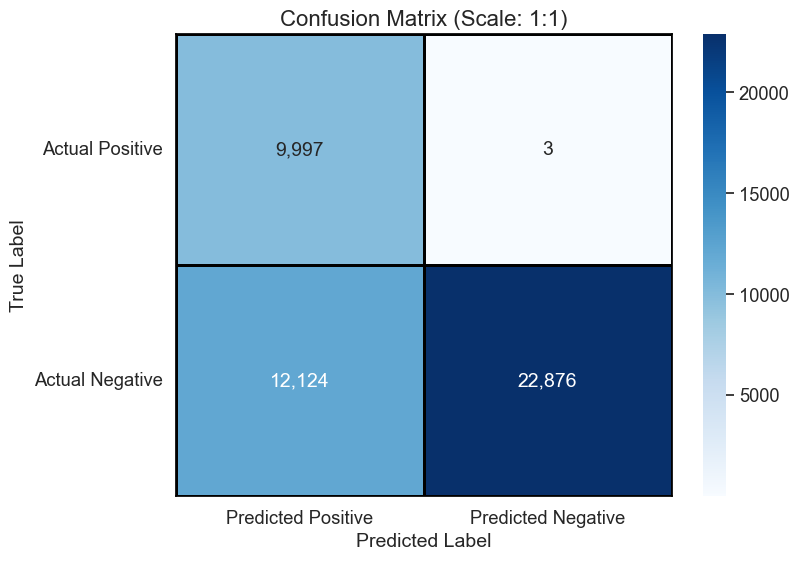

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 混淆矩阵数据
confusion_matrix = np.array([
    [9997, 3],  # 实际正类（第一行）
    [12124,     22876]    # 实际负类（第二行）
])

# 可视化设置
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
ax = sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt=",d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    annot_kws={"size": 14}
)

# 坐标轴标签
ax.set_xticklabels(["Predicted Positive", "Predicted Negative"])
ax.set_yticklabels(["Actual Positive", "Actual Negative"], rotation=0)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix (Scale: 1:1)", fontsize=16)

# 添加边框
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color('black')
    
plt.show()

In [85]:
TP = 9997
TN = 22876
FP = 12124
FN = 3

# 基础计算
total = TP + TN + FP + FN
accuracy = (TP + TN) / total
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f'''
=============== 核心指标 ===============
总样本量: {total:,}
准确率 (Accuracy): {accuracy:.1%}
精确率 (Precision): {precision:.1%} → 每预警2.2次只有1次真实风险
召回率 (Recall): {recall:.1%} → 几乎不漏掉任何真实风险
F1 Score: {f1_score:.3f}

============= 关键特征分析 =============
1️⃣ **极端召回率 (99.97%)**:
   - 仅漏判3个正类样本
   - 适用场景：癌症筛查、航天故障检测等零容忍漏报领域
   '''
)


=============== 核心指标 ===============
总样本量: 45,000
准确率 (Accuracy): 73.1%
精确率 (Precision): 45.2% → 每预警2.2次只有1次真实风险
召回率 (Recall): 100.0% → 几乎不漏掉任何真实风险
F1 Score: 0.622

============= 关键特征分析 =============
1️⃣ **极端召回率 (99.97%)**:
   - 仅漏判3个正类样本
   - 适用场景：癌症筛查、航天故障检测等零容忍漏报领域
   
